### Main libraries and variables

In [31]:
# !pip install torch_geometric torcheval #ax ax-platform # Colab

In [32]:
import torch
import numpy as np
import pandas as pd
import os
import json 
from os.path import dirname
pd.set_option("display.max_columns", None)

DATASET         = f"sp2020"

ROOT_PATH       = f"{dirname(os.getcwd())}/ISG"
# ROOT_PATH       = f"drive/MyDrive/Thesis" 
PROCESSED_PATH  = f"{ROOT_PATH}/data/datasets/processed/{DATASET}"
GRAPHS_PATH     = f"{ROOT_PATH}/data/datasets/graphs/{DATASET}"
MODEL_PATH      = f"{ROOT_PATH}/data/datasets/models/{DATASET}"
RESULT_PATH     = f"{ROOT_PATH}/results/{DATASET}"

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [33]:
PATIENCE = 10
NUM_EPOCHS = 200
TOT_TRIALS = 20

In [34]:
with open(f"{ROOT_PATH}/data/dataset_features.json", 'r') as file:
    dataset_info = json.load(file)[DATASET]

categorical_columns = dataset_info["categorical"]
real_value_columns = dataset_info["numerical"]

tab_all = pd.read_csv(f"{PROCESSED_PATH}/{DATASET}_processed_all.csv")

list_unique = {k : list(tab_all[k].unique()) for k in categorical_columns}

idx_to_activity = {i: name for i, name in enumerate(list_unique["Activity"])} # Index-activity map

In [35]:
outputcat  = {k: len(list_unique[k]) for k in categorical_columns if k in ("Activity", "org:resource")}
outputreal = [k for k in real_value_columns if k == "time:timestamp"]

# +1 adds the end node
outputcat["Activity"] = outputcat["Activity"] + 1

In [36]:
import random

torch.manual_seed(0)
torch.cuda.manual_seed(0)
random.seed(0)
np.random.seed(0)


from torch_geometric.data.hetero_data import HeteroData

torch.serialization.add_safe_globals([HeteroData])

from torch_geometric.loader import DataLoader

### Loading graphs

In [37]:
X_TRAIN = torch.load(f"{GRAPHS_PATH}/train_set.pt", weights_only=False)
X_VALID = torch.load(f"{GRAPHS_PATH}/validation_set.pt", weights_only=False)
X_TEST  = torch.load(f"{GRAPHS_PATH}/test_set.pt", weights_only=False)

In [38]:
edge_types = set()
node_types = set()
for i in range(len(X_TRAIN)):
    n, edge_type = X_TRAIN[i].metadata()
    for x in n:
        node_types.add(x)
    for x in edge_type:
        edge_types.add(x)
for i in range(len(X_VALID)):
    n, edge_type = X_VALID[i].metadata()
    for x in n:
        node_types.add(x)
    for x in edge_type:
        edge_types.add(x)
for i in range(len(X_TEST)):
    n, edge_type = X_TEST[i][0].metadata()
    for x in n:
        node_types.add(x)
    for x in edge_type:
        edge_types.add(x)

NODE_TYPES = list(node_types)
EDGE_TYPES = list(edge_types)

In [39]:
# todo ADD END NODE?

### Hyperopt

In [40]:
from ax.service.managed_loop import optimize
from torch_geometric.nn import (
    HeteroConv,
    GATv2Conv,global_mean_pool
)
from torch.nn import (
    ModuleList,
    Module,
    Linear,
    ModuleDict,
  )
from typing_extensions import Self

from torcheval.metrics.functional import multiclass_accuracy  
import torch.nn as nn
from copy import deepcopy
from tqdm.notebook import tqdm
from time import time

from torch.nn.functional import l1_loss
from torcheval.metrics.functional import multiclass_f1_score 

In [41]:
class HGNN(Module):

    def __init__(self, output_cat, output_real, nodes_relations, parameters) -> Self:
        super().__init__()

        # Hyperparameters
        hid = parameters["hid"]
        layers = parameters["layers"]
        aggregation = parameters["aggregation"]

        # Set model outputs
        self.output_cat = output_cat
        self.output_real = output_real

        # Create convolutional layers
        self.convs = ModuleList()
        for _ in range(layers):
            # For each layer create a convolutional step (GATv2Conv) for each relationship type
            conv = HeteroConv(
                {
                    relation: (
                        GATv2Conv(
                            (-1, -1), hid, 1, False, add_self_loops=False, residual=False
                        )
                    )
                    for relation in nodes_relations
                },
                aggr=aggregation,
            )

            self.convs.append(conv)

        self.FC = ModuleDict()

        # Create a linear layer based on the output type
        for k in output_cat:
            self.FC[k] = Linear(hid, output_cat[k]) # Logits
        for k in output_real:
            self.FC[k] = Linear(hid, 1)             # Number


    def forward(self, batch):
        """
        Each convolutional layer:
        Takes the current node features (x_dict, a dict of node_type → tensor)
        Passes messages along edges (edge_index_dict, a dict of relation → edge list)
        Updates every node's embedding based on its neighbors
        Applies ReLU activation to introduce non-linearity
        """
        x_dict = batch.x_dict  # local copy

        for conv in self.convs:
            x_dict = conv(x_dict, batch.edge_index_dict)
            x_dict = {key: x.relu() for key, x in x_dict.items()}

        output = {}

        for k in self.output_cat:
            output[k] = global_mean_pool(x_dict[k], batch[k].batch)
            output[k] = self.FC[k](output[k])
        for k in self.output_real:
            output[k] = global_mean_pool(x_dict[k], batch[k].batch)
            output[k] = self.FC[k](output[k]).reshape(1, -1)[0]

        return output

In [42]:
from tqdm.notebook import tqdm

# Training

In [43]:
def train_hgnn(config, output_cat, output_real):
    print(config)

    # Instantiate the HGNN
    net = HGNN(
        parameters=config,
        output_cat=output_cat,
        output_real=output_real,
        nodes_relations=EDGE_TYPES,
    )
    net = net.to(device)

    # Asssign loss functions to the categories
    losses = {}
    for k in output_cat:
        losses[k] = nn.CrossEntropyLoss()
    for k in output_real:
        losses[k] = nn.L1Loss()

    # Data loading (automatical batches splitting!!)
    # In this case the DataLoader takes a batch of separate graph objects and merges them into one big disconnected graph.
    train_loader = DataLoader(X_TRAIN, batch_size=config["batch_size"], 
                          shuffle=True, num_workers=8, pin_memory=True)
    valid_loader = DataLoader(X_VALID, batch_size=config["batch_size"], 
                          shuffle=True, num_workers=8, pin_memory=True)
    
    # Adam optimizer + scheduler
    optimizer = torch.optim.Adam(
        net.parameters(), lr=config["lr"]
    )
    lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,mode="min", patience=int(PATIENCE/2)
    )
    
    # Trackers
    best_model = None
    best_loss = 0
    best_f1 = 0
    patience = PATIENCE
    pat_count = 0

    torch.cuda.empty_cache()
    training_times = []
    
    
    # TRAINING
    for epoch in tqdm(range(0, NUM_EPOCHS)):
        net.train()

        # == Inner training step ==
        for _, x in enumerate(train_loader):
            x = x.to(device)
            labels = x.y
            optimizer.zero_grad()
            
            # Forward pass!!
            outputs = net(x)

            # Compute each loss individually then total it
            losses_step = {k: losses[k](outputs[k], labels[k]) for k in losses}
            total_loss = 0
            for k in losses_step:
                total_loss += losses_step[k]

            # Compute gradients via backpropagation
            total_loss.backward()
            # Update parameters 
            optimizer.step()

        
        # Setup
        running_total_loss = []
        predictions_categorical = {k: [] for k in output_cat}
        target_categorical = {k: [] for k in output_cat}
        avg_MAE = {k : [] for k in output_real}
        prediction_numerical = {k: [] for k in output_real}
        target_numerical = {k: [] for k in output_real}
        

        # == Validation step ==
        net.eval()
        with torch.no_grad():
            for i, x in enumerate(valid_loader):
                x = x.to(device)
                labels = x.y
                
                # Forward pass
                outputs = net(x)

                # Compute loss
                losses_step = {k: losses[k](outputs[k], labels[k]) for k in losses}
                running_total_loss.append(sum(list(losses_step.values())))
            
                # INDENTING IT FORWARD BUT I DON'T KNOW IF THIS IS CORRECT
                for k in output_cat:
                    predictions_categorical[k].append(
                            torch.argmax(torch.softmax(outputs[k], dim=1), 1)
                    )
                    target_categorical[k].append(labels[k])
                
                
                for k in output_real:
                    prediction_numerical[k].append(
                        outputs[k]
                    )
                    target_numerical[k].append(
                        labels[k]
                    )

        
        # Mean loss in validation step, used to handle learning rate
        val_loss = sum(running_total_loss) / len(running_total_loss)
        lr_scheduler.step(val_loss)
        
        """
        torch.cat concatenates a list of tensors along dimension 0. 
        The pattern here is: during the loop you append per-batch tensors to a list, 
        then after the loop you join them into one big tensor covering the whole 
        validation set — standard practice in PyTorch evaluation. 
        """
        for k in predictions_categorical:
            predictions_categorical[k] = torch.cat(predictions_categorical[k])
            target_categorical[k] = torch.cat(target_categorical[k])
                
        for k in prediction_numerical:
            prediction_numerical[k] = torch.cat(prediction_numerical[k])
            target_numerical[k] = torch.cat(target_numerical[k])
    
        
       
        # == Metrics computation ==

        # averages the F1 score of each class equally,        
        macro_f1s = {
            k : multiclass_f1_score(
                predictions_categorical[k],
                target_categorical[k].squeeze(),
                num_classes=output_cat[k],
                average='macro'
            ) 
            for k in output_cat
        }
        f1_activity = macro_f1s["Activity"]
        
        
        # fraction of correct predictions
        accuracy = {
                k: multiclass_accuracy(
                    predictions_categorical[k],
                    target_categorical[k].squeeze(),
                    num_classes=output_cat[k],
                )
                for k in output_cat
            }
        
        # MAE recomputation
        MAE = {
            k: l1_loss(prediction_numerical[k], target_numerical[k]).item()
            for k in output_real
        }


        # == Metrics check ==
        if epoch == 0:
            best_model = deepcopy(net)
            best_loss = val_loss
            best_f1 = f1_activity
            print("/"*10)
            print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
            print("Acc", accuracy)
            print("F1s", macro_f1s)
            print("MAE", MAE)
            print(f"Patience {pat_count}/{patience}, val loss {val_loss} current_lr {lr_scheduler.get_last_lr()}, curr_best_activity_F1 {best_f1}")
        else:
            
            if val_loss < best_loss:
                best_loss = val_loss
                best_model = deepcopy(net)
                pat_count = -1
            if best_f1 < f1_activity:
                best_f1 = f1_activity

            print("/"*10)
            print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
            print("Acc", accuracy)
            print("F1s", macro_f1s)
            print("MAE", MAE)
            print(f"Patience {pat_count}/{patience}, val loss {val_loss} current_lr {lr_scheduler.get_last_lr()}, curr_best_activity_F1 {best_f1}")
            if pat_count == patience:
                return ({"valid_loss" : best_loss.item()} , best_model)
        pat_count += 1
    print("Acc", accuracy)
    print("F1s", macro_f1s)
    print("MAE", MAE)
    print(f"Patience {pat_count}/{patience}, val loss {val_loss} current_lr {lr_scheduler.get_last_lr()}, curr_best_activity_F1 {best_f1}")
    return ({"valid_loss" : best_loss.item()} , best_model)
   

In [14]:
import logging

logging.getLogger("root").setLevel(logging.ERROR)

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

## (stop execution here to not redo param hyperopt)

In [81]:
def train_evaluate(config):
    res, _ = train_hgnn(config, output_cat=outputcat, output_real=outputreal)
    return res
    """
    For graph data specifically (PyTorch Geometric), the DataLoader does something extra:
    it takes a batch of separate graph objects and merges them into one big disconnected graph.
    """

In [82]:
# Hyperparameters optimization (Ax)
best_parameters, values, experiment, model = optimize(
    parameters=[
        {"name": "hid", "type": "choice", "values": [128, 256, 512], "value_type": "int", "is_ordered": True, "sort_values": False},
        {"name": "batch_size", "type": "choice", "values": [256, 512, 1024], "value_type": "int", "is_ordered": True, "sort_values": False},
        {"name": "layers", "type": "choice", "values": [2,4], "value_type": "int", "is_ordered" : True, "sort_values":False},
        {"name": "lr", "type": "range", "bounds": [1e-4, 1e-2], "value_type": "float", "log_scale": True},
        {"name": "aggregation", "type" : "choice", "values" :["sum", "mean", "max"], "value_type" : "str"},
    ],
  
    evaluation_function=train_evaluate,
    objective_name='valid_loss',
    arms_per_trial=1,
    minimize = True,
    random_seed = 123,
    total_trials = TOT_TRIALS
)

print(best_parameters)
means, covariances = values
print(means)
print(experiment)

""" To cut on time
best_parameters = {
    "hid": 128,
    "layers": 2,
    "lr": 1e-3,
    "aggregation": "mean",
    "batch_size": 128,
}
"""

/home/luca.dariz-1/ISG/venv/lib/python3.12/site-packages/ax/service/utils/instantiation.py:248: AxParameterWarning: `is_ordered` is not specified for `ChoiceParameter` "aggregation". Defaulting to `False`  since the parameter is a string with more than 2 choices.. To override this behavior (or avoid this warning), specify `is_ordered` during `ChoiceParameter` construction. Note that choice parameters with exactly 2 choices are always considered ordered and that the user-supplied `is_ordered` has no effect in this particular case.
  return ChoiceParameter(
/home/luca.dariz-1/ISG/venv/lib/python3.12/site-packages/ax/service/utils/instantiation.py:248: AxParameterWarning: `sort_values` is not specified for `ChoiceParameter` "aggregation". Defaulting to `False` for parameters of `ParameterType` STRING. To override this behavior (or avoid this warning), specify `sort_values` during `ChoiceParameter` construction.
  return ChoiceParameter(
[INFO 06-30 11:39:32] ax.service.utils.instantiation

{'hid': 128, 'batch_size': 512, 'layers': 2, 'lr': 0.009578778465390004, 'aggregation': 'sum'}


  0%|          | 0/200 [00:00<?, ?it/s]

//////////
Epoch 1/200
Acc {'org:resource': tensor(0.5353, device='cuda:0'), 'Activity': tensor(0.7867, device='cuda:0')}
F1s {'org:resource': tensor(0.5345, device='cuda:0'), 'Activity': tensor(0.2628, device='cuda:0')}
MAE {'time:timestamp': 0.3697495758533478}
Patience 0/10, val loss 7.489534378051758 current_lr [0.009578778465390004], curr_best_activity_F1 0.262778639793396
//////////
Epoch 2/200
Acc {'org:resource': tensor(0.6901, device='cuda:0'), 'Activity': tensor(0.8303, device='cuda:0')}
F1s {'org:resource': tensor(0.6901, device='cuda:0'), 'Activity': tensor(0.3123, device='cuda:0')}
MAE {'time:timestamp': 0.5170195698738098}
Patience 1/10, val loss 9.186558723449707 current_lr [0.009578778465390004], curr_best_activity_F1 0.3123422861099243
//////////
Epoch 3/200
Acc {'org:resource': tensor(0.8923, device='cuda:0'), 'Activity': tensor(0.8816, device='cuda:0')}
F1s {'org:resource': tensor(0.8857, device='cuda:0'), 'Activity': tensor(0.4296, device='cuda:0')}
MAE {'time:times

[INFO 06-30 11:41:11] ax.service.managed_loop: Running optimization trial 2...


...

[INFO 06-30 13:34:40] ax.service.managed_loop: Running optimization trial 20...


//////////
Epoch 22/200
Acc {'org:resource': tensor(0.9858, device='cuda:0'), 'Activity': tensor(0.7937, device='cuda:0')}
F1s {'org:resource': tensor(0.9852, device='cuda:0'), 'Activity': tensor(0.5180, device='cuda:0')}
MAE {'time:timestamp': 0.007772095967084169}
Patience 10/10, val loss 1.223982334136963 current_lr [0.00038900987492848643], curr_best_activity_F1 0.5304580330848694
{'hid': 256, 'batch_size': 1024, 'layers': 4, 'lr': 0.0002551557334761881, 'aggregation': 'mean'}


  0%|          | 0/200 [00:00<?, ?it/s]

//////////
Epoch 1/200
Acc {'org:resource': tensor(0.5975, device='cuda:0'), 'Activity': tensor(0.2173, device='cuda:0')}
F1s {'org:resource': tensor(0.4932, device='cuda:0'), 'Activity': tensor(0.0482, device='cuda:0')}
MAE {'time:timestamp': 0.026484135538339615}
Patience 0/10, val loss 3.4961471557617188 current_lr [0.0002551557334761881], curr_best_activity_F1 0.048188433051109314
//////////
Epoch 2/200
Acc {'org:resource': tensor(0.6120, device='cuda:0'), 'Activity': tensor(0.2024, device='cuda:0')}
F1s {'org:resource': tensor(0.3797, device='cuda:0'), 'Activity': tensor(0.0227, device='cuda:0')}
MAE {'time:timestamp': 0.021482404321432114}
Patience -1/10, val loss 3.080379009246826 current_lr [0.0002551557334761881], curr_best_activity_F1 0.048188433051109314
//////////
Epoch 3/200
Acc {'org:resource': tensor(0.6126, device='cuda:0'), 'Activity': tensor(0.2038, device='cuda:0')}
F1s {'org:resource': tensor(0.3941, device='cuda:0'), 'Activity': tensor(0.0226, device='cuda:0')}
MAE

' To cut on time\nbest_parameters = {\n    "hid": 128,\n    "layers": 2,\n    "lr": 1e-3,\n    "aggregation": "mean",\n    "batch_size": 128,\n}\n'

In [83]:
from ax.service.utils.report_utils import exp_to_df

results = exp_to_df(experiment)

[WARNING 06-30 13:40:26] ax.service.utils.report_utils: Column reason missing for all trials. Not appending column.


In [84]:
results.sort_values(by="valid_loss")

,trial_index,arm_name,trial_status,generation_method,valid_loss,hid,batch_size,layers,lr,aggregation
17,17,17_0,COMPLETED,BoTorch,0.247699,512,1024,4,0.000207,mean
13,13,13_0,COMPLETED,BoTorch,0.253784,512,1024,4,0.000100,mean
1,1,1_0,COMPLETED,Sobol,0.255572,512,256,4,0.000263,max
12,12,12_0,COMPLETED,BoTorch,0.255660,512,256,4,0.000314,max
15,15,15_0,COMPLETED,BoTorch,0.256487,128,1024,4,0.000152,mean
19,19,19_0,COMPLETED,BoTorch,0.263757,256,1024,4,0.000255,mean
0,0,0_0,COMPLETED,Sobol,0.285561,128,512,2,0.009579,sum
14,14,14_0,COMPLETED,BoTorch,0.285574,256,1024,4,0.000681,mean
8,8,8_0,COMPLETED,Sobol,0.307237,128,1024,4,0.001567,mean
3,3,3_0,COMPLETED,Sobol,0.316181,256,512,4,0.000623,mean


In [85]:
results = results.sort_values(by="valid_loss")

In [86]:
if not os.path.isdir(f"{ROOT_PATH}/results/{DATASET}"):
    os.mkdir(f"{ROOT_PATH}/results/{DATASET}")

In [ ]:
results.to_csv(f"{RESULT_PATH}/hyp_params_search.csv", sep=",", index=False)

In [ ]:
with open(f"{RESULT_PATH}/best_parameters.csv", "w") as f:
    json.dump(best_parameters, f, indent=4)

In [89]:
with open(f"{ROOT_PATH}/results/{DATASET}/best_parameters.csv", "r") as f:
    best_parameters = json.load(f)
_,net = train_hgnn(best_parameters,outputcat,outputreal)
torch.save(net.state_dict(), f"{MODEL_PATH}/model.pt")

{'hid': 512, 'batch_size': 1024, 'layers': 4, 'lr': 0.0002067416912929947, 'aggregation': 'mean'}


  0%|          | 0/200 [00:00<?, ?it/s]

//////////
Epoch 1/200
Acc {'org:resource': tensor(0.6227, device='cuda:0'), 'Activity': tensor(0.2194, device='cuda:0')}
F1s {'org:resource': tensor(0.4310, device='cuda:0'), 'Activity': tensor(0.0262, device='cuda:0')}
MAE {'time:timestamp': 0.03027009777724743}
Patience 0/10, val loss 3.317599058151245 current_lr [0.0002067416912929947], curr_best_activity_F1 0.026178685948252678
//////////
Epoch 2/200
Acc {'org:resource': tensor(0.6214, device='cuda:0'), 'Activity': tensor(0.2041, device='cuda:0')}
F1s {'org:resource': tensor(0.4338, device='cuda:0'), 'Activity': tensor(0.0226, device='cuda:0')}
MAE {'time:timestamp': 0.042646490037441254}
Patience -1/10, val loss 2.74357271194458 current_lr [0.0002067416912929947], curr_best_activity_F1 0.026178685948252678
//////////
Epoch 3/200
Acc {'org:resource': tensor(0.6142, device='cuda:0'), 'Activity': tensor(0.2176, device='cuda:0')}
F1s {'org:resource': tensor(0.4611, device='cuda:0'), 'Activity': tensor(0.0244, device='cuda:0')}
MAE {'

# Test 

In [44]:
import sklearn.preprocessing

# The one in dp
def get_one_hot_encoder(dataset, key):
    datas = dataset[key].unique()                   # Get all the values a key could have
    if key == "Activity":                           # Add the END node
        datas = np.union1d(datas, ["END"])         
    datas = datas.astype(np.str_)                   # Make everything a string
    datas = datas.reshape([len(datas), 1])          # Add a dimension
    onehot = sklearn.preprocessing.OneHotEncoder()  # Learn and return
    onehot.fit(datas)
    return onehot

def to_onehot(logits, n_classes):
    idx = torch.argmax(logits, dim=1).item() 
    oh = torch.zeros(1, n_classes)
    oh[0, idx] = 1.0
    return oh

ONE_HOT_ENCODERS = {k: get_one_hot_encoder(tab_all, k) for k in categorical_columns}
print(ONE_HOT_ENCODERS["Activity"].categories_[0].tolist())
END_IDX = int(ONE_HOT_ENCODERS["Activity"].transform([["END"]]).argmax())
print(f"END class index: {END_IDX}")

['Approved', 'Completed', 'Creation', 'DeviceReceived', 'END', 'FreeticketComp', 'FreeticketCust', 'InDelivery', 'Letter', 'NoteHotline', 'NoteWorkshop', 'StatusRequest', 'StockEntry', 'Transmission']
END class index: 4


In [45]:
# The one in dp, but modified to handle dynamic trace nodes (that do not 'grow')
def compute_edges_indexs(node_features, prefix_len):
    res = {}
    keys = node_features.keys()
    for k in keys:
        n_k = len(node_features[k])
        if n_k != 1:
            if k == "Activity":
                res[(k, "followed_by", k)] = [[i, i + 1] for i in range(prefix_len - 1)]
                for k2 in keys:
                    if k2 != k:
                        n_k2 = len(node_features[k2])
                        if n_k2 == 1:
                            res[(k, "related_to", k2)] = [[i, 0] for i in range(prefix_len)]
                        else:
                            last = n_k2 - 1
                            res[(k, "related_to", k2)] = [[i, min(i, last)] for i in range(prefix_len)]
            else:
                # self-relation tra nodi dello stesso tipo, basata sulla lunghezza VERA, non su prefix_len
                res[(k, "related_to", k)] = [[i, i + 1] for i in range(n_k - 1)]
    return res

In [46]:
from torch_geometric.transforms import ToUndirected
def append_predicted_event(g, out, outputcat, outputreal):
    new_g = HeteroData()

    # --- Nodi ---
    for node_type in g.node_types:
        existing = g[node_type].x.detach().cpu()

        if node_type == "Activity":
            # Sempre un nuovo nodo
            new_feat = to_onehot(out[node_type], outputcat[node_type])
            new_g[node_type].x = torch.cat([existing, new_feat], dim=0)

        elif existing.shape[0] == 1:
            # Nodo statico: rimane invariato, non si tocca
            new_g[node_type].x = existing

        elif node_type in outputcat:
            # Dinamico categorico: appendi sempre (no dedup, coerente col training)
            new_feat = to_onehot(out[node_type], outputcat[node_type])
            new_g[node_type].x = torch.cat([existing, new_feat], dim=0)

        elif node_type in outputreal:
            # Dinamico numerico: appendi
            new_feat = out[node_type].reshape(1, 1).detach().cpu()
            new_g[node_type].x = torch.cat([existing, new_feat], dim=0)

        else:
            # Tipo non gestito: copia invariato
            new_g[node_type].x = existing

    # --- Edge: ricostruzione da zero (evita bug rev edges) ---
    prefix_len = new_g["Activity"].x.shape[0]
    node_features_proxy = {nt: new_g[nt].x for nt in new_g.node_types}
    edges = compute_edges_indexs(node_features_proxy, prefix_len)

    for rel, edge_list in edges.items():
        src_nodes = [pair[0] for pair in edge_list]
        dst_nodes = [pair[1] for pair in edge_list]
        new_g[rel].edge_index = torch.tensor(
            [src_nodes, dst_nodes], dtype=torch.long
        )

    new_g = ToUndirected()(new_g)
    return new_g

In [47]:
from data.drawer import drawer
from Levenshtein import distance

def seq_levenshtein(seq1, seq2):
    """Levenshtein distance su sequenze di interi."""
    s1 = "".join(chr(i + 256) for i in seq1)
    s2 = "".join(chr(i + 256) for i in seq2)
    return distance(s1, s2)

In [ ]:
from torch_geometric.data import Batch

def test_hgnn(net, output_cat, output_real, max_steps=100):
    """
    Per ogni traccia nel test set:
      - parte dal prefisso di 2 eventi
      - predice il prossimo evento
      - lo appende al grafo
      - ripete finché predice END o raggiunge max_steps
      - confronta con il ground truth
    """
    net.eval()
    all_predicted_act = []
    all_ground_truth_act = []
    lev_act = []
    lev_res = []
    mae_stepbystep = []
    mae_remaining = []
    trace_len  = []
    end_reached = 0

    with torch.no_grad():
        for graph, ground_truth in tqdm(X_TEST):
            current_graph = graph.clone()
            predicted_activities = []
            predicted_resources  = []
            predicted_timestamps = []

            for _ in range(max_steps):
                batched = Batch.from_data_list([current_graph]).to(device)
                output = net(batched)

                pred_act = torch.argmax(output["Activity"], dim=-1).item()
                pred_res = torch.argmax(output["org:resource"], dim=-1).item()
                pred_time = output["time:timestamp"].item()

                predicted_activities.append(pred_act)
                predicted_resources.append(pred_res)
                predicted_timestamps.append(pred_time)

                if pred_act == END_IDX:
                    end_reached += 1
                    break

                output_cpu = {k: v.cpu() for k, v in output.items()}
                current_graph = append_predicted_event(
                    current_graph, output_cpu, output_cat, output_real
                )

            gt_activities = [torch.argmax(v).item() for v in ground_truth["Activity"]][2:]
            gt_resources = (
                [torch.argmax(ground_truth["org:resource"][i]).item() for i in range(2, len(ground_truth["org:resource"]))] 
                if "org:resource" in ground_truth and len(ground_truth["org:resource"]) > 1 
                else [torch.argmax(ground_truth["org:resource"][0]).item()] * len(gt_activities) 
                if "org:resource" in ground_truth
                else []
            )
            gt_timestamps = (
                [ground_truth["time:timestamp"][i].item() for i in range(2, len(ground_truth["time:timestamp"]))] 
                if "time:timestamp" in ground_truth 
                else []
            )

            # Metrics
            lev_act.append(seq_levenshtein(predicted_activities, gt_activities))
            if gt_resources:
                lev_res.append(seq_levenshtein(predicted_resources, gt_resources))

            if gt_timestamps:
                min_len = min(len(predicted_timestamps), len(gt_timestamps))
                mae_sbs = sum(abs(predicted_timestamps[i] - gt_timestamps[i]) for i in range(min_len)) / min_len
                mae_stepbystep.append(mae_sbs)

                mae_remaining.append(
                    abs(sum(predicted_timestamps) - sum(gt_timestamps))
                )
            
            trace_len.append(len(gt_activities))
            all_predicted_act.append(predicted_activities)
            all_ground_truth_act.append(gt_activities)
        
    n = len(X_TEST)
    res = {
        "n_traces":              n,
        "avg_trace_len":         sum(trace_len) / n,
        "end_not_reached":       n - end_reached,
        "lev_act_mean":          sum(lev_act) / n,
        "lev_act_std":           float(torch.tensor(lev_act, dtype=torch.float).std()),
        "lev_res_mean":          sum(lev_res) / len(lev_res) if lev_res else None,
        "lev_res_std":           float(torch.tensor(lev_res, dtype=torch.float).std()) if lev_res else None,
        "mae_stepbystep_mean":   sum(mae_stepbystep) / len(mae_stepbystep) if mae_stepbystep else None,
        "mae_stepbystep_std":    float(torch.tensor(mae_stepbystep, dtype=torch.float).std()) if mae_stepbystep else None,
        "mae_remaining_mean":    sum(mae_remaining) / len(mae_remaining) if mae_remaining else None,
        "mae_remaining_std":     float(torch.tensor(mae_remaining, dtype=torch.float).std()) if mae_remaining else None,
    }

    print("\n" + "="*45)
    print(f"  AUTOREGRESSIVE INFERENCE RESULTS ({n} traces)")
    print("="*45)
    print(f"  End not reached {res['end_not_reached']} times")
    print(f"  Average trace length (gt)  : {res['avg_trace_len']:.3f}")
    print(f"  Levenshtein Activity  : {res['lev_act_mean']:.3f} ± {res['lev_act_std']:.3f}")
    if res["lev_res_mean"] is not None:
        print(f"  Levenshtein Resource  : {res['lev_res_mean']:.3f} ± {res['lev_res_std']:.3f}")
    if res["mae_stepbystep_mean"] is not None:
        print(f"  MAE step-by-step      : {res['mae_stepbystep_mean']:.4f} ± {res['mae_stepbystep_std']:.4f}")
    if res["mae_remaining_mean"] is not None:
        print(f"  MAE remaining time    : {res['mae_remaining_mean']:.4f} ± {res['mae_remaining_std']:.4f}")
    print("="*45)

    return res, all_predicted_act, all_ground_truth_act

### For testing simplicity, skip otherwise

In [49]:
with open(f"{RESULT_PATH}/best_parameters.csv", "r") as f:
    best_parameters = json.load(f)

# Instantiate the HGNN
net = HGNN(
    parameters=best_parameters,
    output_cat=outputcat,
    output_real=outputreal,
    nodes_relations=EDGE_TYPES,
)
net.load_state_dict(torch.load(f"{MODEL_PATH}/model.pt", map_location=device, weights_only=False))
net = net.to(device)
net.eval()

HGNN(
  (convs): ModuleList(
    (0-3): 4 x HeteroConv(num_relations=12)
  )
  (FC): ModuleDict(
    (Activity): Linear(in_features=512, out_features=14, bias=True)
    (org:resource): Linear(in_features=512, out_features=12, bias=True)
    (time:timestamp): Linear(in_features=512, out_features=1, bias=True)
  )
)

In [ ]:
res, pred_act, gt_act = test_hgnn(
    net,
    outputcat,
    outputreal,
)

with open(f"{RESULT_PATH}/inference_results.json", "w") as f:
    json.dump(res, f, indent=2)

with open(f"{RESULT_PATH}/all_predicted_act.json", "w") as f:
    json.dump(pred_act, f)

with open(f"{RESULT_PATH}/all_ground_truth_act.json", "w") as f:
    json.dump(gt_act, f)

  0%|          | 0/4782 [00:00<?, ?it/s]

In [ ]:
breakpoint()

## Test on 10 models

In [ ]:
import pandas

def create_df(results):
    res = {}
    for k in results[0]:
        res[k] = [x[k] for x in results]
    print(res)
    res = pandas.DataFrame(data=res)
    
    return res, res.mean(), res.std()
        

In [ ]:
def test_multi(config, outputcat, outputreal, num_runs=10):

    res = []

    for i in range(num_runs):

        print(f"Run {i}")

        _,net = train_hgnn(
                config,
                outputcat,
                outputreal,
            )

        res.append(
            test_hgnn(
                net,
                outputcat,
                outputreal,
            )
        )

        print("RES:")
        print(res[-1])


    results_table, means, stds = create_df(res)

    results_table.to_csv(f"{RESULT_PATH}/results.csv", sep=",", index=False)

    pd.DataFrame(data={"mean" : means, "std" : stds}).to_csv(f"{RESULT_PATH}/mean_and_stds.csv", sep=",")

    print(pd.DataFrame(data={"mean" : means, "std" : stds}))


    return res

In [ ]:
breakpoint()

# ====== Scraps area ======

In [ ]:
from data.drawer import drawer
from Levenshtein import distance

def seq_levenshtein(seq1, seq2):
    """Levenshtein distance su sequenze di interi."""
    s1 = "".join(chr(i + 256) for i in seq1)
    s2 = "".join(chr(i + 256) for i in seq2)
    return distance(s1, s2)


def inference_single(net, g, t, max_steps=100):
    net.eval()
    current_graph = g.clone()

    predicted_activities = []
    predicted_resources  = []
    predicted_timestamps = []

    with torch.no_grad():
        for step in range(max_steps):
            batched = Batch.from_data_list([current_graph]).to(device)
            output = net(batched)

            pred_act = torch.argmax(output["Activity"], dim=-1).item()
            pred_res = torch.argmax(output["org:resource"], dim=-1).item()
            pred_time = output["time:timestamp"].item()
            predicted_activities.append(pred_act)
            predicted_resources.append(pred_res)
            predicted_timestamps.append(pred_time)

            pred_str = ONE_HOT_ENCODERS["Activity"].categories_[0][pred_act]
            print(f"Step {step+1}: {pred_str} (class {pred_act}) (res {pred_res}) (time {pred_time})")

            if pred_act == END_IDX:
                print("→ END predicted, stopping")
                break

            output_cpu = {k: v.cpu() for k, v in output.items()}
            current_graph = append_predicted_event(
                current_graph, output_cpu, outputcat, outputreal
            )
        else:
            print(f"→ max_steps ({max_steps}) reached without END")

    # Ground truth — skip i primi 2 eventi (già nel prefisso)
    act_cats     = ONE_HOT_ENCODERS["Activity"].categories_[0]
    gt_activities = [torch.argmax(v).item() for v in t["Activity"]][2:]
    gt_timestamps = [t["time:timestamp"][i].item()
                     for i in range(2, len(t["time:timestamp"]))] if "time:timestamp" in t else []
    if "org:resource" in t: # solving compression problem
        if len(t["org:resource"]) > 1:
            # Normal case: 1 resource per event. Skip the 2 prefix events.
            gt_resources = [
                torch.argmax(t["org:resource"][i]).item() 
                for i in range(2, len(t["org:resource"]))
            ]
        else:
            # Optimized case: length is 1. Get that single resource and repeat it.
            single_res = torch.argmax(t["org:resource"][0]).item()
            gt_resources = [single_res] * len(gt_activities)
    else:
        gt_resources = []

    gt_strings   = [act_cats[i] for i in gt_activities]
    pred_strings = [act_cats[i] for i in predicted_activities]

    print("\n--- Ground Truth (suffix) ---")
    for i, (idx, name) in enumerate(zip(gt_activities, gt_strings)):
        print(f"  {i+1}: {name} (class {idx})")

    print("\n--- Predicted ---")
    for i, (idx, name) in enumerate(zip(predicted_activities, pred_strings)):
        print(f"  {i+1}: {name} (class {idx})")

    print(f"\nGT length:   {len(gt_activities)}")
    print(f"Pred length: {len(predicted_activities)}")

    # --- Metriche ---
    print(f"\nLevenshtein (Activity):  {seq_levenshtein(predicted_activities, gt_activities)}")
    print(f"Levenshtein (Resource):  {seq_levenshtein(predicted_resources, gt_resources)}")
    min_len = min(len(predicted_timestamps), len(gt_timestamps))
    mae = sum(abs(predicted_timestamps[i] - gt_timestamps[i]) for i in range(min_len)) / min_len
    print(f"MAE (Timestamp):         {mae:.4f}")

    drawer(current_graph)

    return predicted_activities, gt_activities


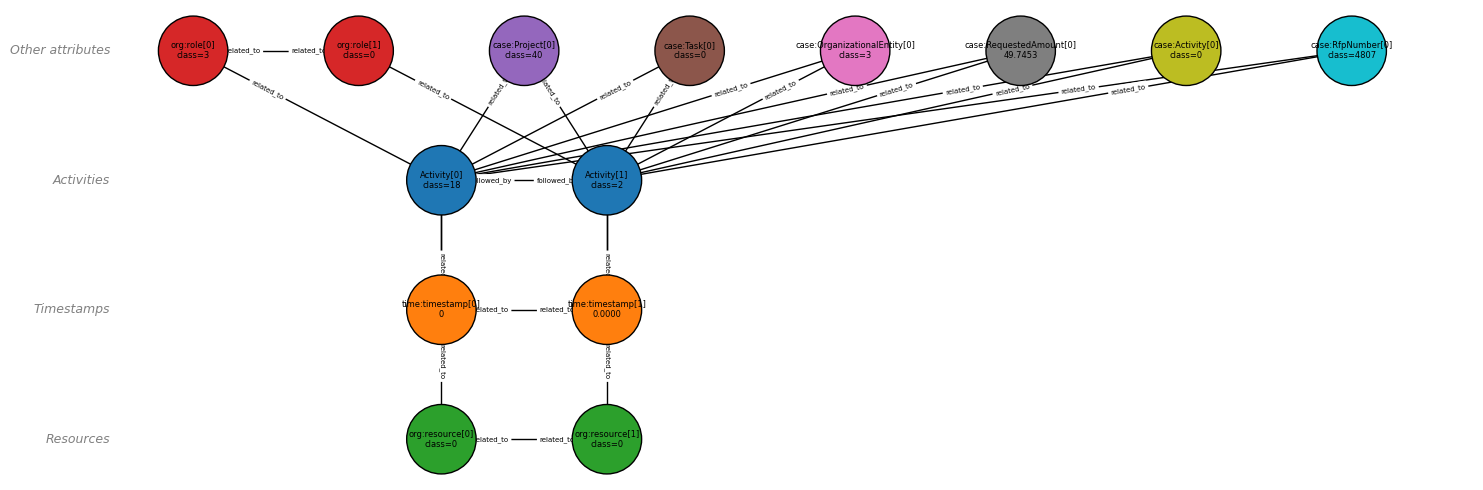

In [ ]:
g,t = X_TEST[5]
drawer(g)

Step 1: Request For Payment FINAL_APPROVED by SUPERVISOR (class 8) (res 0) (time -0.005060282070189714)
Step 2: Request Payment (class 19) (res 1) (time 0.003313861321657896)
Step 3: Payment Handled (class 1) (res 1) (time 0.03128964826464653)
Step 4: Request Payment (class 19) (res 0) (time 0.0363612100481987)
Step 5: Request Payment (class 19) (res 1) (time 0.06662585586309433)
Step 6: Request Payment (class 19) (res 1) (time 0.07069075852632523)
Step 7: Request Payment (class 19) (res 1) (time 0.08346357941627502)
Step 8: Payment Handled (class 1) (res 1) (time 0.08609035611152649)
Step 9: END (class 0) (res 1) (time 0.10630744695663452)
→ END predicted, stopping

--- Ground Truth (suffix) ---
  1: Request For Payment FINAL_APPROVED by SUPERVISOR (class 8)
  2: Request Payment (class 19)
  3: Payment Handled (class 1)
  4: END (class 0)

--- Predicted ---
  1: Request For Payment FINAL_APPROVED by SUPERVISOR (class 8)
  2: Request Payment (class 19)
  3: Payment Handled (class 1)
  

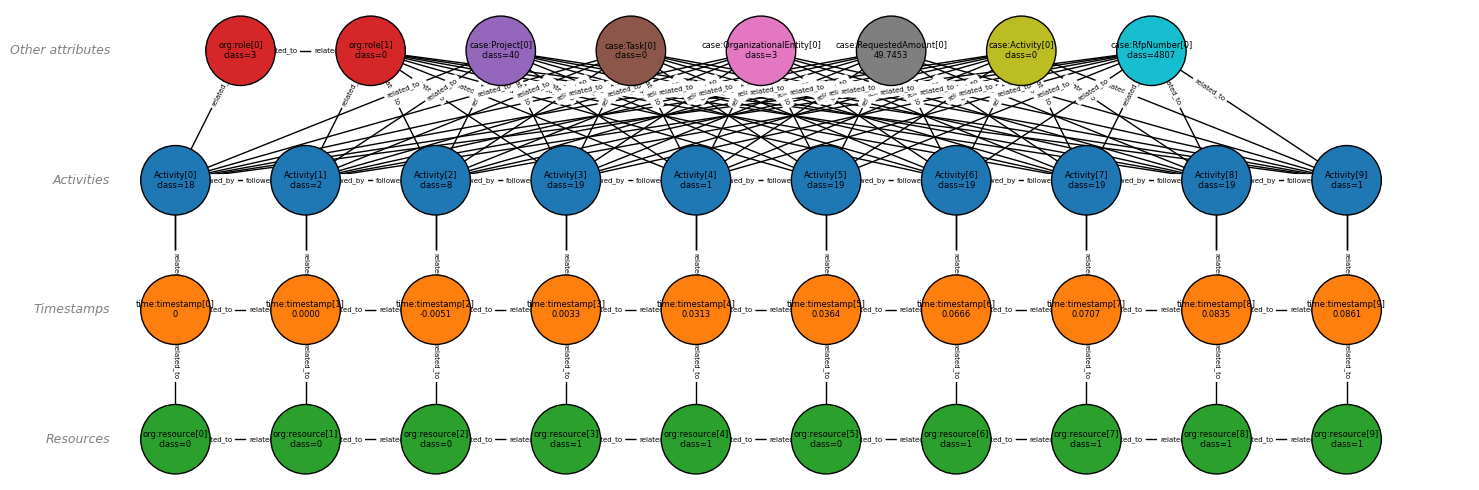

In [ ]:
pred, gt = inference_single(net, g, t)

In [ ]:
"""
def test_hgnn(net, output_cat, output_real):

    # Assign loss functions to the categories
    losses = {}
    for k in output_cat:
        losses[k] = nn.CrossEntropyLoss()
    for k in output_real:
        losses[k] = nn.L1Loss()

    # Empty dictionaries to store tensors
    predictions_categorical = {k: [] for k in output_cat}
    target_categorical = {k: [] for k in output_cat}

    # avg_MAE = {k: [] for k in output_real}
    prediction_numerical = {k: [] for k in output_real}
    target_numerical = {k: [] for k in output_real}

    running_total_loss = []

    # Data loading (batches)
    test_loader = DataLoader([pair[0] for pair in X_TEST], 128, shuffle=False)
    
    # TESTING LOOP
    net.eval()
    with torch.no_grad():
        for i, x in enumerate(test_loader):
            x = x.to(device)
            labels = x.y

            # Forward pass
            outputs = net(x)

            # Compute loss
            losses_step = {k: losses[k](outputs[k], labels[k]) for k in losses}
            running_total_loss.append(sum(list(losses_step.values())))
        
            # INDENTING IT FORWARD BUT I DON'T KNOW IF THIS IS CORRECT
            for k in output_cat:
                predictions_categorical[k].append(
                        torch.argmax(torch.softmax(outputs[k], dim=1), 1)
                )
                target_categorical[k].append(labels[k])
            
            
            for k in output_real:
                prediction_numerical[k].append(
                    outputs[k]
                )
                target_numerical[k].append(
                    labels[k]
                )
    
    # Tensors merging
    for k in predictions_categorical:
        predictions_categorical[k] = torch.cat(predictions_categorical[k])
        target_categorical[k] = torch.cat(target_categorical[k])
            
    for k in prediction_numerical:
        prediction_numerical[k] = torch.cat(prediction_numerical[k])
        target_numerical[k] = torch.cat(target_numerical[k])
    
    # Metrics computation
    macro_f1s = {
        k : multiclass_f1_score(
            predictions_categorical[k],
            target_categorical[k].squeeze(),
            num_classes=output_cat[k],
            average='macro'
        )
        for k in output_cat
    }
        
    accuracy = {
            k: multiclass_accuracy(
                predictions_categorical[k],
                target_categorical[k].squeeze(),
                num_classes=output_cat[k],
            )
            for k in output_cat
        }
        
    MAE = {
        k: l1_loss(prediction_numerical[k], target_numerical[k]).item()
        for k in output_real
    }
    
    # avg_MAE = {k: sum(avg_MAE[k]) / len(avg_MAE[k]) for k in avg_MAE}

    Average_total_loss = sum(running_total_loss) / len(running_total_loss)

    res = (
        {f"{k}_acc": accuracy[k].item() for k in accuracy}
        | {f"{k}_macroF1": macro_f1s[k].item() for k in macro_f1s}
        | {f"{k}_mae": avg_MAE[k] for k in avg_MAE}
        | {"AVG_total_loss": Average_total_loss.item()}
        | {f"MAE_{k}": MAE[k] for k in MAE}
    )

    print(res)

    return res
"""

'\ndef test_hgnn(net, output_cat, output_real):\n\n    # Assign loss functions to the categories\n    losses = {}\n    for k in output_cat:\n        losses[k] = nn.CrossEntropyLoss()\n    for k in output_real:\n        losses[k] = nn.L1Loss()\n\n    # Empty dictionaries to store tensors\n    predictions_categorical = {k: [] for k in output_cat}\n    target_categorical = {k: [] for k in output_cat}\n\n    # avg_MAE = {k: [] for k in output_real}\n    prediction_numerical = {k: [] for k in output_real}\n    target_numerical = {k: [] for k in output_real}\n\n    running_total_loss = []\n\n    # Data loading (batches)\n    test_loader = DataLoader([pair[0] for pair in X_TEST], 128, shuffle=False)\n    \n    # TESTING LOOP\n    net.eval()\n    with torch.no_grad():\n        for i, x in enumerate(test_loader):\n            x = x.to(device)\n            labels = x.y\n\n            # Forward pass\n            outputs = net(x)\n\n            # Compute loss\n            losses_step = {k: losses[

In [ ]:
print("DATASET:", DATASET)
print("outputcat:", outputcat)
print("END_IDX:", END_IDX)
print("ONE_HOT_ENCODERS Activity categories:", ONE_HOT_ENCODERS["Activity"].categories_[0].tolist())
print("net FC Activity out_features:", net.FC["Activity"].out_features)

DATASET: BPI20_RequestForPayment
outputcat: {'org:resource': 2, 'Activity': 20}
END_IDX: 0
ONE_HOT_ENCODERS Activity categories: ['END', 'Payment Handled', 'Request For Payment APPROVED by ADMINISTRATION', 'Request For Payment APPROVED by BUDGET OWNER', 'Request For Payment APPROVED by PRE_APPROVER', 'Request For Payment APPROVED by SUPERVISOR', 'Request For Payment FINAL_APPROVED by BUDGET OWNER', 'Request For Payment FINAL_APPROVED by DIRECTOR', 'Request For Payment FINAL_APPROVED by SUPERVISOR', 'Request For Payment FOR_APPROVAL by ADMINISTRATION', 'Request For Payment FOR_APPROVAL by SUPERVISOR', 'Request For Payment REJECTED by ADMINISTRATION', 'Request For Payment REJECTED by BUDGET OWNER', 'Request For Payment REJECTED by EMPLOYEE', 'Request For Payment REJECTED by MISSING', 'Request For Payment REJECTED by PRE_APPROVER', 'Request For Payment REJECTED by SUPERVISOR', 'Request For Payment SAVED by EMPLOYEE', 'Request For Payment SUBMITTED by EMPLOYEE', 'Request Payment']
net FC A